In [10]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pylab as plt
import networkx as nx
from sklearn.metrics import pairwise_distances
from sklearn.decomposition import PCA
from sklearn.neighbors import kneighbors_graph

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
from modules import geometry
from modules import metrics
from modules import visualization as vis
from modules.projector import MDSTorusProjector
from modules import apsp_distance_matrix

In [12]:
# quick helper to compute stress --> needed?
def torus_stress(X, D, proj):
    geod = geometry.make_torus_geod(proj.alpha_, proj.r0_, proj.r1_, proj.theta_)
    return metrics.geodesic_stress(X, D, geod)

In [13]:
# load data
a = np.load("grid_cells_4800.npz")
data = a['data']
spikes = a['spikes']
cell_ids = [
    5, 39,
    75, 109, 115] # cells with clearly structured firing pattern

In [14]:
# Ambient space Euclidean distances

In [15]:
D_grid = pairwise_distances(data)

In [16]:
## Square torus

In [17]:
proj = MDSTorusProjector()
X = proj.fit_transform(D_grid)
stress = torus_stress(X, D_grid, proj)
print(f"stress={stress:.4g}")

stress=0.2545


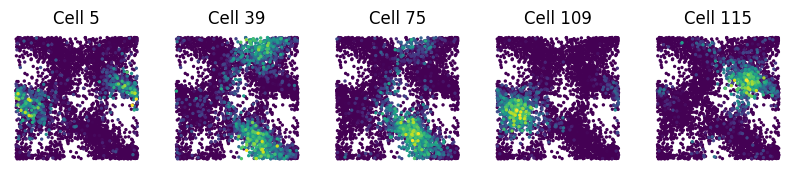

In [18]:
# spatial location of firing rates
fig, ax = plt.subplots(1, 5, figsize=(10, 3))

xx = X[:,0]
yy = X[:,1]
for i, idx in enumerate(cell_ids):
    order  = np.argsort(spikes[:, idx])  # to plot interesting time points on top
    vis.plot_embedding_with_torus_edges(torus=proj, ax=ax[i], order=order, colors=spikes[:, idx], edge_alpha=0.35, s=2)
    ax[i].set_title(f"Cell {idx}")
    ax[i].axis("off")
    ax[i].set_aspect("equal")
#fig.suptitle(f"Firing rates of selected cells on square torus\n Toroidal embedding, stress={stress:.4g}", dpi=300)

In [19]:
## Rhombic torus with 60 fixed angle

In [20]:
proj_fix_rhombus = MDSTorusProjector()
X_fix_rhombus = proj_fix_rhombus.fit_transform(D_grid, learn_mode='alpha', theta=60.0)

In [21]:
fix_rhombus_stress = torus_stress(X_fix_rhombus, D_grid, proj_fix_rhombus)
print(f"stress={fix_rhombus_stress:.4g}")

stress=0.2137


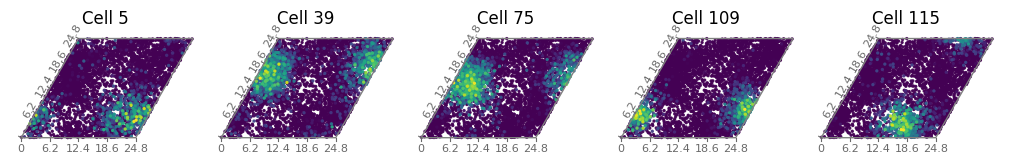

In [41]:
fig, ax = plt.subplots(1, 5, figsize=(10, 3), constrained_layout=True)

for i, idx in enumerate(cell_ids):
    order  = np.argsort(spikes[:, idx])  # to plot interesting time points on top
    vis.plot_embedding_with_torus_edges(torus=proj_fix_rhombus, ax=ax[i], order=order, colors=spikes[:, idx], edge_alpha=0.35, s=2)
    ax[i].set_title(f"Cell {idx}")
#fig.suptitle(f"Firing rates of selected cells by spatial position\n Fixed rhombic embedding (theta=60.0) Stress={fix_rhombus_stress:.4g}")

In [23]:
## Rhombic torus with learned angle

In [24]:
proj_rhombus = MDSTorusProjector()
X_rhombus = proj_rhombus.fit_transform(D_grid, learn_mode='rhombic', theta=80.0)
rhombic_stress = torus_stress(X_rhombus, D_grid, proj_rhombus)
print(f"stress={rhombic_stress:.4g}")
print(f"theta = {np.degrees(proj_rhombus.theta_)}")

stress=0.2126
theta = 61.69781434853977


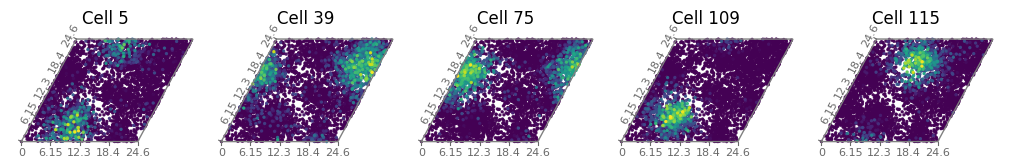

In [42]:
fig, ax = plt.subplots(1, 5, figsize=(10, 3), constrained_layout=True)

for i, idx in enumerate(cell_ids):
    order  = np.argsort(spikes[:, idx])  # to plot interesting time points on top
    vis.plot_embedding_with_torus_edges(torus=proj_rhombus, ax=ax[i], order=order, colors=spikes[:, idx], edge_alpha=0.35, s=2)
    ax[i].set_title(f"Cell {idx}")
#fig.suptitle(f"Firing rates of selected cells\n Learned rhombic embedding Stress={rhombic_stress:.4g}, Theta={np.degrees(proj_rhombus.theta_):.4g}")

In [26]:
## Learn full parallelogram

In [27]:
proj_para = MDSTorusProjector()
X_para = proj_para.fit_transform(D_grid, learn_mode='parallelogram', theta=80.0)

In [28]:
para_stress = torus_stress(X_para, D_grid, proj_para)
print(f"stress={para_stress:.4g}")
print(f"theta = {np.degrees(proj_para.theta_)}")

stress=0.2128
theta = 61.805308266680036


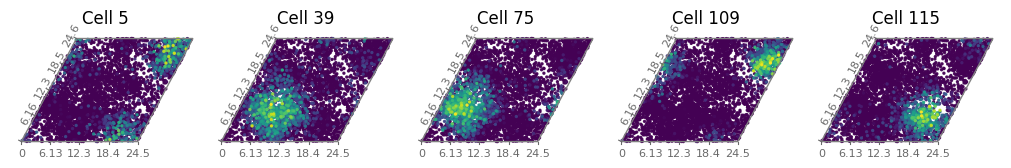

In [43]:
fig, ax = plt.subplots(1, 5, figsize=(10, 3), constrained_layout=True)
for i, idx in enumerate(cell_ids):
    order  = np.argsort(spikes[:, idx])  # to plot interesting time points on top
    vis.plot_embedding_with_torus_edges(torus=proj_para, ax=ax[i], order=order, colors=spikes[:, idx], edge_alpha=0.35, s=2)
    ax[i].set_title(f"Cell {idx}")
#fig.suptitle(f"Firing rates of selected cells by spatial position\n Learned parallelogram embedding Stress={para_stress:.4g}, theta={np.degrees(proj_para.theta_):.4g}")

In [30]:
# kNN graph + apsp

In [31]:
k = 15
A_geo = kneighbors_graph(data, n_neighbors=k, mode='distance', include_self=False)
A_geo = A_geo.maximum(A_geo.T)  # symmetrize, weights = euclidean edge lengths
G_geo = nx.from_scipy_sparse_array(A_geo)

D_geo, _ = apsp_distance_matrix(G_geo, method="scipy")

assert not np.isinf(D_geo).any(), "kNN graph is disconnected, increase k"
print(D_geo.shape, f"max geodesic: {D_geo.max():.0f}")

(4800, 4800) max geodesic: 27


In [ ]:
## Square torus

In [32]:
proj_geo = MDSTorusProjector()
embd_geo = proj_geo.fit_transform(D_geo)
stress_geo = torus_stress(embd_geo, D_geo, proj_geo)
print(f"stress={stress_geo:.4g}")

stress=0.2362


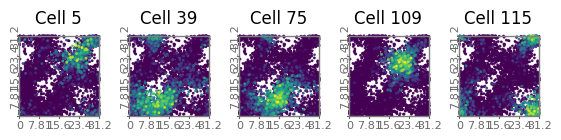

In [48]:
fig, ax = plt.subplots(1, 5, figsize=(5.5, 3), constrained_layout=True)

for i, idx in enumerate(cell_ids):
    order  = np.argsort(spikes[:, idx])  # to plot interesting time points on top
    vis.plot_embedding_with_torus_edges(torus=proj_geo, ax=ax[i], order=order, colors=spikes[:, idx], edge_alpha=0.35, s=1)
    ax[i].set_title(f"Cell {idx}")
#fig.suptitle(f"Firing rates of selected cells\n Square embedding, kNN graph Stress={stress_geo:.4g}")

In [35]:
## Parallelogram torus

In [36]:
proj_geo_para = MDSTorusProjector()
embd_geo_para = proj_geo_para.fit_transform(D_geo, learn_mode='parallelogram', theta=80.0) # deliberate init theta different from 60
stress_geo_para = torus_stress(embd_geo_para, D_geo, proj_geo_para)
print(f"stress={stress_geo_para:.4g}")
print(f"theta = {np.degrees(proj_geo_para.theta_)}")

stress=0.155
theta = 61.28128231672822


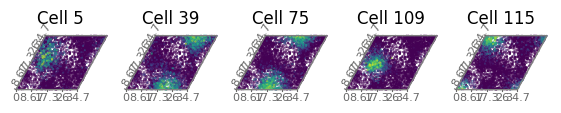

In [46]:
fig, ax = plt.subplots(1, 5, figsize=(5.5, 3), constrained_layout=True)

for i, idx in enumerate(cell_ids):
    order  = np.argsort(spikes[:, idx])  # to plot interesting time points on top
    vis.plot_embedding_with_torus_edges(torus=proj_geo_para, ax=ax[i], order=order, colors=spikes[:, idx], edge_alpha=0.35, s=0.1)
    ax[i].set_title(f"Cell {idx}")
#fig.suptitle(f"Firing rates of selected cells\n Parallelogram embedding, kNN graph, Stress={stress_geo_para:.4g}, theta={np.degrees(proj_geo_para.theta_):.4g}")